<a href="https://colab.research.google.com/github/hariharan-vs/Deep-learning-lab/blob/main/Experiment_6_24BAD030_%20LSTM_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hariharan V S - 24BAD030 
Vocabulary Size: 10000
Maximum Sequence Length: 200

===== DATASET INFORMATION =====
Training samples: 25000
Testing samples : 25000

===== SENTIMENT DISTRIBUTION =====
Training Positive: 12500
Training Negative: 12500
Testing Positive : 12500
Testing Negative : 12500

===== DATA SHAPE =====
X_train shape: (25000,)
y_train shape: (25000,)
X_test shape : (25000,)
y_test shape : (25000,)
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

===== SAMPLE REVIEWS =====

Review 1
----------------------------------------------------------------------
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought

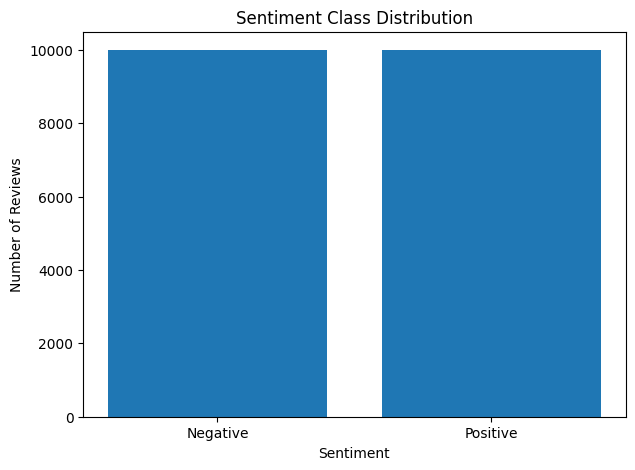


PART A COMPLETED SUCCESSFULLY
Dataset              : IMDB Movie Reviews
Vocabulary Size      : 10000
Maximum Sequence     : 200
Training Samples     : 20000
Validation Samples   : 5000
Testing Samples      : 25000
Sentiment Classes    : 2
0                    : Negative
1                    : Positive
Padding              : Completed
Label Encoding       : Completed
Train/Test Split     : Completed


In [2]:
print("Hariharan V S - 24BAD030 ")
# ============================================================
# PART A: DATASET PREPARATION AND TEXT PREPROCESSING
# LSTM FOR SENTIMENT ANALYSIS
# ============================================================

# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split


# -------------------------------
# 2. PARAMETERS
# -------------------------------

VOCAB_SIZE = 10000
MAX_LENGTH = 200

print("Vocabulary Size:", VOCAB_SIZE)
print("Maximum Sequence Length:", MAX_LENGTH)


# -------------------------------
# 3. LOAD IMDB DATASET
# -------------------------------

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("\n===== DATASET INFORMATION =====")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# -------------------------------
# 4. CHECK SENTIMENT DISTRIBUTION
# -------------------------------

print("\n===== SENTIMENT DISTRIBUTION =====")

print("Training Positive:", np.sum(y_train == 1))
print("Training Negative:", np.sum(y_train == 0))

print("Testing Positive :", np.sum(y_test == 1))
print("Testing Negative :", np.sum(y_test == 0))


# -------------------------------
# 5. DISPLAY DATASET SHAPE
# -------------------------------

print("\n===== DATA SHAPE =====")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)


# -------------------------------
# 6. GET WORD INDEX
# -------------------------------

word_index = imdb.get_word_index()

# Reverse the dictionary
reverse_word_index = {
    value: key for key, value in word_index.items()
}


# -------------------------------
# 7. FUNCTION TO DECODE REVIEW
# -------------------------------

def decode_review(encoded_review):

    decoded_words = []

    for index in encoded_review:

        # IMDB reserves indexes 0, 1 and 2
        word = reverse_word_index.get(index - 3, "?")

        decoded_words.append(word)

    return " ".join(decoded_words)


# -------------------------------
# 8. DISPLAY SAMPLE REVIEWS
# -------------------------------

print("\n===== SAMPLE REVIEWS =====")

for i in range(3):

    print("\nReview", i + 1)
    print("-" * 70)

    print(decode_review(X_train[i]))

    if y_train[i] == 1:
        print("\nSentiment: POSITIVE")
    else:
        print("\nSentiment: NEGATIVE")


# -------------------------------
# 9. DISPLAY REVIEW LENGTH
# -------------------------------

print("\n===== REVIEW LENGTH =====")

train_lengths = [len(review) for review in X_train]

print("Minimum review length:", min(train_lengths))
print("Maximum review length:", max(train_lengths))
print("Average review length:", np.mean(train_lengths))


# -------------------------------
# 10. BASIC TEXT PREPROCESSING
# -------------------------------

# Since the Keras IMDB dataset is already converted
# into numerical word sequences, we demonstrate
# lowercase and special-character cleaning using
# decoded sample text.

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


sample_text = decode_review(X_train[0])

cleaned_text = clean_text(sample_text)

print("\n===== PREPROCESSED SAMPLE =====")
print(cleaned_text)


# -------------------------------
# 11. TOKENIZATION / NUMERICAL SEQUENCES
# -------------------------------

print("\n===== TOKENIZED SEQUENCE =====")

print("Original sequence:")
print(X_train[0][:30])

print("\nSequence length:")
print(len(X_train[0]))


# -------------------------------
# 12. BUILD VOCABULARY
# -------------------------------

print("\n===== VOCABULARY =====")

print("Total words in IMDB word index:",
      len(word_index))

print("First 20 words in vocabulary:")

for word, index in list(word_index.items())[:20]:

    print(word, ":", index)


# -------------------------------
# 13. LIMIT VOCABULARY
# -------------------------------

# Only keep the first VOCAB_SIZE words.
# Reviews are already represented using
# numerical word indexes.

X_train_limited = []

for review in X_train:

    limited_review = [
        word if word < VOCAB_SIZE else 2
        for word in review
    ]

    X_train_limited.append(limited_review)


X_test_limited = []

for review in X_test:

    limited_review = [
        word if word < VOCAB_SIZE else 2
        for word in review
    ]

    X_test_limited.append(limited_review)


# -------------------------------
# 14. SEQUENCE PADDING
# -------------------------------

X_train_padded = pad_sequences(
    X_train_limited,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

X_test_padded = pad_sequences(
    X_test_limited,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)


# -------------------------------
# 15. DISPLAY PADDING RESULTS
# -------------------------------

print("\n===== PADDING RESULTS =====")

print("Before padding:")
print("First review length:", len(X_train[0]))

print("\nAfter padding:")
print("First review length:", len(X_train_padded[0]))

print("\nTraining data shape:",
      X_train_padded.shape)

print("Testing data shape:",
      X_test_padded.shape)


# -------------------------------
# 16. DISPLAY PADDED SEQUENCE
# -------------------------------

print("\n===== PADDED SEQUENCE =====")

print(X_train_padded[0])


# -------------------------------
# 17. ENCODE SENTIMENT LABELS
# -------------------------------

# IMDB already provides:
# 0 = Negative
# 1 = Positive

y_train = np.array(y_train).astype("int32")
y_test = np.array(y_test).astype("int32")

print("\n===== LABEL ENCODING =====")

print("First 10 training labels:")
print(y_train[:10])

print("\n0 = Negative")
print("1 = Positive")


# -------------------------------
# 18. TRAIN / VALIDATION SPLIT
# -------------------------------

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_padded,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)


# -------------------------------
# 19. DISPLAY FINAL DATA SHAPES
# -------------------------------

print("\n===== FINAL DATASET SPLIT =====")

print("Training data   :", X_train_final.shape)
print("Training labels :", y_train_final.shape)

print("Validation data :", X_val.shape)
print("Validation labels:", y_val.shape)

print("Testing data    :", X_test_padded.shape)
print("Testing labels  :", y_test.shape)


# -------------------------------
# 20. FINAL CLASS DISTRIBUTION
# -------------------------------

print("\n===== FINAL CLASS DISTRIBUTION =====")

print("Training Positive:",
      np.sum(y_train_final == 1))

print("Training Negative:",
      np.sum(y_train_final == 0))

print("Validation Positive:",
      np.sum(y_val == 1))

print("Validation Negative:",
      np.sum(y_val == 0))

print("Testing Positive:",
      np.sum(y_test == 1))

print("Testing Negative:",
      np.sum(y_test == 0))


# -------------------------------
# 21. VISUALIZE CLASS DISTRIBUTION
# -------------------------------

labels = ['Negative', 'Positive']

train_counts = [
    np.sum(y_train_final == 0),
    np.sum(y_train_final == 1)
]

plt.figure(figsize=(7, 5))

plt.bar(labels, train_counts)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()


# -------------------------------
# 22. FINAL SUMMARY
# -------------------------------

print("\n" + "=" * 60)
print("PART A COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Dataset              : IMDB Movie Reviews")
print("Vocabulary Size      :", VOCAB_SIZE)
print("Maximum Sequence     :", MAX_LENGTH)
print("Training Samples     :", len(X_train_final))
print("Validation Samples   :", len(X_val))
print("Testing Samples      :", len(X_test_padded))
print("Sentiment Classes    : 2")
print("0                    : Negative")
print("1                    : Positive")
print("Padding              : Completed")
print("Label Encoding       : Completed")
print("Train/Test Split     : Completed")
print("=" * 60)

===== EMBEDDING PARAMETERS =====
Vocabulary Size     : 10000
Embedding Dimension : 128
Maximum Sequence    : 200

Embedding layer created successfully.

===== SAMPLE INPUT =====
Input shape:
(1, 200)

First 20 tokens:
[   1  806    8  135   13   28   57  326   51  363    9  399  252  202
  178  102   40 1354  778  449]

===== EMBEDDING REPRESENTATION =====
Embedded output shape:
(1, 200, 128)

===== EMBEDDING SHAPE EXPLANATION =====
Number of reviews       : 1
Sequence length         : 200
Embedding vector size   : 128

Final embedding shape:
(Number of Reviews, Sequence Length, Embedding Dimension)
(1, 200, 128)

===== FIRST WORD EMBEDDING =====
First word embedding vector:
[-0.01553416 -0.02870867 -0.04256662 -0.00153263  0.04604194  0.02746854
  0.01553097 -0.04311411 -0.02280854 -0.03526993 -0.00256811  0.038196
  0.00242641  0.00774061  0.03719361  0.01167712  0.04989262  0.04799009
 -0.00388256 -0.01862097 -0.04151455  0.00538608 -0.04133929 -0.01543651
  0.04535674 -0.01032934  

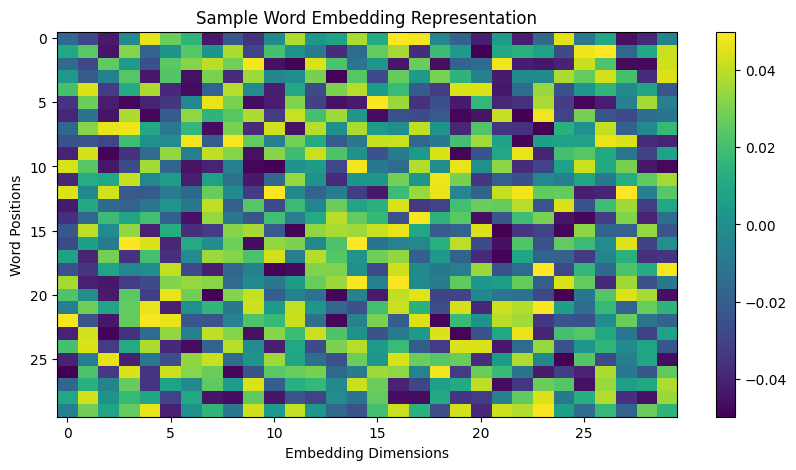


PART B COMPLETED SUCCESSFULLY
Embedding Layer       : Created
Vocabulary Size       : 10000
Embedding Dimension   : 128
Sequence Length       : 200
Embedding Output      : (1, 200, 128)
Dense Representation  : Generated


In [3]:
# ============================================================
# PART B: EMBEDDING GENERATION
# LSTM FOR SENTIMENT ANALYSIS
# ============================================================

# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


# -------------------------------
# 2. EMBEDDING PARAMETERS
# -------------------------------

VOCAB_SIZE = 10000
EMBEDDING_DIM = 128
MAX_LENGTH = 200

print("===== EMBEDDING PARAMETERS =====")
print("Vocabulary Size     :", VOCAB_SIZE)
print("Embedding Dimension :", EMBEDDING_DIM)
print("Maximum Sequence    :", MAX_LENGTH)


# -------------------------------
# 3. CREATE EMBEDDING LAYER
# -------------------------------

embedding_layer = tf.keras.layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM
)

print("\nEmbedding layer created successfully.")


# -------------------------------
# 4. SELECT SAMPLE INPUT
# -------------------------------

# X_train_final was created in Part A

sample_input = X_train_final[:1]

print("\n===== SAMPLE INPUT =====")

print("Input shape:")
print(sample_input.shape)

print("\nFirst 20 tokens:")
print(sample_input[0][:20])


# -------------------------------
# 5. CONVERT TOKENS TO EMBEDDINGS
# -------------------------------

embedded_output = embedding_layer(sample_input)

print("\n===== EMBEDDING REPRESENTATION =====")

print("Embedded output shape:")
print(embedded_output.shape)


# -------------------------------
# 6. EXPLAIN EMBEDDING SHAPE
# -------------------------------

print("\n===== EMBEDDING SHAPE EXPLANATION =====")

print("Number of reviews       : 1")
print("Sequence length         :", MAX_LENGTH)
print("Embedding vector size   :", EMBEDDING_DIM)

print("\nFinal embedding shape:")
print(
    "(Number of Reviews, Sequence Length, Embedding Dimension)"
)

print(
    embedded_output.shape
)


# -------------------------------
# 7. DISPLAY FIRST WORD VECTOR
# -------------------------------

print("\n===== FIRST WORD EMBEDDING =====")

first_word_vector = embedded_output[0, 0].numpy()

print("First word embedding vector:")
print(first_word_vector)

print("\nVector length:")
print(len(first_word_vector))


# -------------------------------
# 8. DISPLAY FIRST 5 WORD VECTORS
# -------------------------------

print("\n===== FIRST 5 WORD EMBEDDINGS =====")

for i in range(5):

    print("\nWord position:", i)

    print(
        embedded_output[0, i].numpy()
    )


# -------------------------------
# 9. EMBEDDING STATISTICS
# -------------------------------

embedding_numpy = embedded_output.numpy()

print("\n===== EMBEDDING STATISTICS =====")

print("Minimum value:",
      np.min(embedding_numpy))

print("Maximum value:",
      np.max(embedding_numpy))

print("Mean value:",
      np.mean(embedding_numpy))

print("Standard deviation:",
      np.std(embedding_numpy))


# -------------------------------
# 10. DISPLAY EMBEDDING MATRIX
# -------------------------------

print("\n===== EMBEDDING MATRIX =====")

print("Embedding matrix shape:")
print(embedded_output.shape)


# -------------------------------
# 11. VISUALIZE PART OF EMBEDDING
# -------------------------------

plt.figure(figsize=(10, 5))

plt.imshow(
    embedding_numpy[0, :30, :30],
    aspect='auto'
)

plt.title("Sample Word Embedding Representation")
plt.xlabel("Embedding Dimensions")
plt.ylabel("Word Positions")

plt.colorbar()

plt.show()


# -------------------------------
# 12. FINAL SUMMARY
# -------------------------------

print("\n" + "=" * 60)
print("PART B COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Embedding Layer       : Created")
print("Vocabulary Size       :", VOCAB_SIZE)
print("Embedding Dimension   :", EMBEDDING_DIM)
print("Sequence Length       :", MAX_LENGTH)
print("Embedding Output      :", embedded_output.shape)
print("Dense Representation  : Generated")
print("=" * 60)

In [4]:
# ============================================================
# PART C: IMPLEMENTING THE LSTM MODEL
# LSTM FOR SENTIMENT ANALYSIS
# ============================================================

# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import numpy as np
import tensorflow as tf


# -------------------------------
# 2. DEFINE PARAMETERS
# -------------------------------

VOCAB_SIZE = 10000
MAX_LENGTH = 200
EMBEDDING_DIM = 128
LSTM_UNITS = 64

print("===== MODEL PARAMETERS =====")

print("Vocabulary Size     :", VOCAB_SIZE)
print("Maximum Sequence    :", MAX_LENGTH)
print("Embedding Dimension :", EMBEDDING_DIM)
print("LSTM Units          :", LSTM_UNITS)


# -------------------------------
# 3. CREATE LSTM MODEL
# -------------------------------

model = tf.keras.Sequential([

    # Input Layer
    tf.keras.layers.Input(
        shape=(MAX_LENGTH,),
        name="Input_Layer"
    ),

    # Embedding Layer
    tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        name="Embedding_Layer"
    ),

    # LSTM Layer
    tf.keras.layers.LSTM(
        LSTM_UNITS,
        name="LSTM_Layer"
    ),

    # Output Layer
    tf.keras.layers.Dense(
        1,
        activation='sigmoid',
        name="Output_Layer"
    )
])


# -------------------------------
# 4. DISPLAY MODEL ARCHITECTURE
# -------------------------------

print("\n===== MODEL ARCHITECTURE =====")

model.summary()


# -------------------------------
# 5. COMPILE MODEL
# -------------------------------

model.compile(

    optimizer='adam',

    loss='binary_crossentropy',

    metrics=['accuracy']
)


# -------------------------------
# 6. DISPLAY COMPILE INFORMATION
# -------------------------------

print("\n===== MODEL COMPILATION =====")

print("Optimizer : Adam")
print("Loss      : Binary Crossentropy")
print("Metric    : Accuracy")


# -------------------------------
# 7. CHECK MODEL INPUT
# -------------------------------

print("\n===== MODEL INPUT =====")

print("Input shape:")
print(model.input_shape)


# -------------------------------
# 8. CHECK MODEL OUTPUT
# -------------------------------

print("\n===== MODEL OUTPUT =====")

print("Output shape:")
print(model.output_shape)


# -------------------------------
# 9. TEST MODEL WITH SAMPLE DATA
# -------------------------------

sample_data = X_train_final[:5]

sample_prediction = model.predict(
    sample_data,
    verbose=0
)

print("\n===== SAMPLE PREDICTION =====")

for i in range(5):

    probability = sample_prediction[i][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print(
        "Review", i + 1,
        "| Probability:", round(float(probability), 4),
        "| Prediction:", sentiment
    )


# -------------------------------
# 10. FINAL SUMMARY
# -------------------------------

print("\n" + "=" * 60)
print("PART C COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Input Layer       : Created")
print("Embedding Layer   : Created")
print("LSTM Layer        : Created")
print("Dense Layer       : Created")
print("Activation        : Sigmoid")
print("Optimizer         : Adam")
print("Loss              : Binary Crossentropy")
print("Metric            : Accuracy")
print("=" * 60)

===== MODEL PARAMETERS =====
Vocabulary Size     : 10000
Maximum Sequence    : 200
Embedding Dimension : 128
LSTM Units          : 64

===== MODEL ARCHITECTURE =====


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding_Layer (Embedding)     │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_Layer (LSTM)               │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)


===== MODEL COMPILATION =====
Optimizer : Adam
Loss      : Binary Crossentropy
Metric    : Accuracy

===== MODEL INPUT =====
Input shape:
(None, 200)

===== MODEL OUTPUT =====
Output shape:
(None, 1)

===== SAMPLE PREDICTION =====
Review 1 | Probability: 0.5032 | Prediction: Positive
Review 2 | Probability: 0.5 | Prediction: Positive
Review 3 | Probability: 0.4974 | Prediction: Negative
Review 4 | Probability: 0.5041 | Prediction: Positive
Review 5 | Probability: 0.5013 | Prediction: Positive

PART C COMPLETED SUCCESSFULLY
Input Layer       : Created
Embedding Layer   : Created
LSTM Layer        : Created
Dense Layer       : Created
Activation        : Sigmoid
Optimizer         : Adam
Loss              : Binary Crossentropy
Metric            : Accuracy


===== TRAINING PARAMETERS =====
Epochs     : 5
Batch Size : 64

===== MODEL TRAINING =====
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 265ms/step - accuracy: 0.5555 - loss: 0.6800 - val_accuracy: 0.6224 - val_loss: 0.6584
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 265ms/step - accuracy: 0.6079 - loss: 0.6517 - val_accuracy: 0.5528 - val_loss: 0.6936
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 268ms/step - accuracy: 0.7316 - loss: 0.5362 - val_accuracy: 0.8276 - val_loss: 0.4173
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 274ms/step - accuracy: 0.8892 - loss: 0.2886 - val_accuracy: 0.8608 - val_loss: 0.3412
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 279ms/step - accuracy: 0.9359 - loss: 0.1853 - val_accuracy: 0.8620 - val_loss: 0.3552

===== TRAINING HISTORY =====
Training Accuracy:
[0.5555499792098999, 0.6079000234603882, 0.7316499948501587, 0.8892499804496765, 0.935949981212616]

Validation Accuracy:
[0.6223999857902527, 0.5527999997138977, 0.8276000022888184, 0.86080002784729, 0.8619

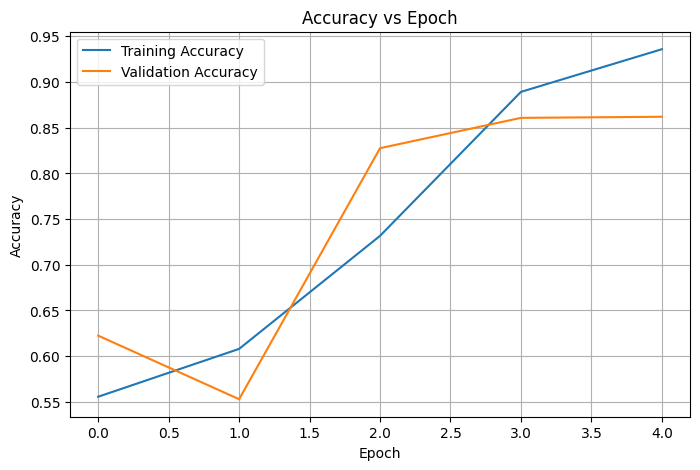

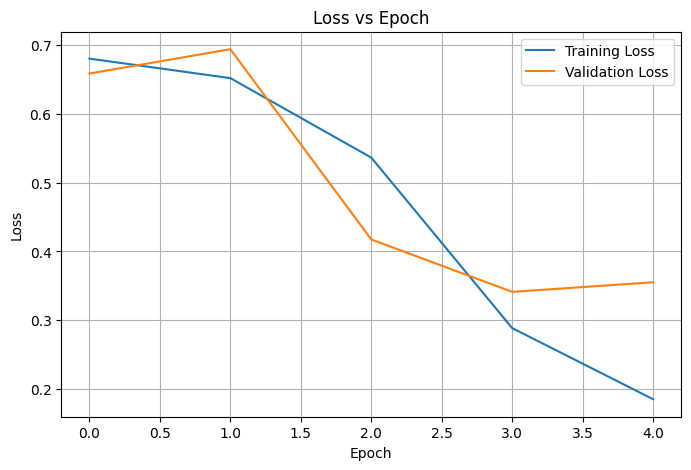


===== TEST DATA EVALUATION =====
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.8556 - loss: 0.3629

Test Loss: 0.3629
Test Accuracy: 0.8556

===== GENERATING PREDICTIONS =====
782/782 ━━━━━━━━━━━━━━━━━━━━ 28s 36ms/step

Predictions generated successfully.

First 20 Predictions:
[0 1 1 0 1 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0]

First 20 Actual Labels:
[0 1 1 0 1 1 1 0 0 1 1 0 0 0 1 0 1 0 0 0]

MODEL EVALUATION METRICS
Accuracy  : 0.8556
Precision : 0.8578
Recall    : 0.8526
F1 Score  : 0.8552

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.86     12500
    Positive       0.86      0.85      0.86     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000


===== CONFUSION MATRIX =====
[[10733  1767]
 [ 1843 10657]]


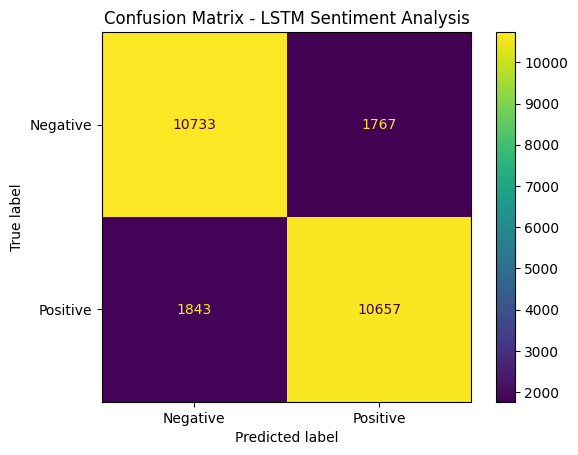


===== SAMPLE SENTIMENT PREDICTION =====

Review:
This movie was absolutely fantastic and amazing.
Predicted Sentiment: Positive
Probability: 0.9773
------------------------------------------------------------

Review:
The movie was boring and very disappointing.
Predicted Sentiment: Negative
Probability: 0.0755
------------------------------------------------------------

Review:
I really enjoyed this movie and the acting was excellent.
Predicted Sentiment: Positive
Probability: 0.981
------------------------------------------------------------

Review:
This was a terrible movie and I hated it.
Predicted Sentiment: Negative
Probability: 0.129
------------------------------------------------------------

PART D COMPLETED SUCCESSFULLY
Training Accuracy : 0.9359
Validation Accuracy : 0.862
Test Accuracy : 0.8556
Precision : 0.8578
Recall : 0.8526
F1 Score : 0.8552


In [5]:
# ============================================================
# PART D: MODEL TRAINING AND SENTIMENT PREDICTION
# LSTM FOR SENTIMENT ANALYSIS
# ============================================================

# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


# -------------------------------
# 2. TRAINING PARAMETERS
# -------------------------------

EPOCHS = 5
BATCH_SIZE = 64

print("===== TRAINING PARAMETERS =====")

print("Epochs     :", EPOCHS)
print("Batch Size :", BATCH_SIZE)


# -------------------------------
# 3. TRAIN THE LSTM MODEL
# -------------------------------

print("\n===== MODEL TRAINING =====")

history = model.fit(

    X_train_final,

    y_train_final,

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    validation_data=(
        X_val,
        y_val
    ),

    verbose=1
)


# -------------------------------
# 4. DISPLAY TRAINING HISTORY
# -------------------------------

print("\n===== TRAINING HISTORY =====")

print(
    "Training Accuracy:"
)

print(
    history.history['accuracy']
)

print(
    "\nValidation Accuracy:"
)

print(
    history.history['val_accuracy']
)

print(
    "\nTraining Loss:"
)

print(
    history.history['loss']
)

print(
    "\nValidation Loss:"
)

print(
    history.history['val_loss']
)


# -------------------------------
# 5. FINAL TRAINING RESULTS
# -------------------------------

final_train_accuracy = (
    history.history['accuracy'][-1]
)

final_val_accuracy = (
    history.history['val_accuracy'][-1]
)

final_train_loss = (
    history.history['loss'][-1]
)

final_val_loss = (
    history.history['val_loss'][-1]
)

print("\n===== FINAL TRAINING RESULTS =====")

print(
    "Training Accuracy :",
    round(final_train_accuracy, 4)
)

print(
    "Validation Accuracy :",
    round(final_val_accuracy, 4)
)

print(
    "Training Loss :",
    round(final_train_loss, 4)
)

print(
    "Validation Loss :",
    round(final_val_loss, 4)
)


# -------------------------------
# 6. ACCURACY VS EPOCH
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Accuracy vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()


# -------------------------------
# 7. LOSS VS EPOCH
# -------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()


# -------------------------------
# 8. EVALUATE TEST DATA
# -------------------------------

print("\n===== TEST DATA EVALUATION =====")

test_loss, test_accuracy = model.evaluate(

    X_test_padded,

    y_test,

    verbose=1
)

print(
    "\nTest Loss:",
    round(test_loss, 4)
)

print(
    "Test Accuracy:",
    round(test_accuracy, 4)
)


# -------------------------------
# 9. GENERATE PREDICTIONS
# -------------------------------

print("\n===== GENERATING PREDICTIONS =====")

y_pred_probability = model.predict(

    X_test_padded,

    verbose=1
)


# Convert probability to class
y_pred = (
    y_pred_probability >= 0.5
).astype(int).flatten()


print("\nPredictions generated successfully.")

print("\nFirst 20 Predictions:")
print(y_pred[:20])

print("\nFirst 20 Actual Labels:")
print(y_test[:20])


# -------------------------------
# 10. CALCULATE ACCURACY
# -------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)


# -------------------------------
# 11. CALCULATE PRECISION
# -------------------------------

precision = precision_score(
    y_test,
    y_pred
)


# -------------------------------
# 12. CALCULATE RECALL
# -------------------------------

recall = recall_score(
    y_test,
    y_pred
)


# -------------------------------
# 13. CALCULATE F1 SCORE
# -------------------------------

f1 = f1_score(
    y_test,
    y_pred
)


# -------------------------------
# 14. DISPLAY EVALUATION METRICS
# -------------------------------

print("\n" + "=" * 60)

print("MODEL EVALUATION METRICS")

print("=" * 60)

print(
    "Accuracy  :",
    round(accuracy, 4)
)

print(
    "Precision :",
    round(precision, 4)
)

print(
    "Recall    :",
    round(recall, 4)
)

print(
    "F1 Score  :",
    round(f1, 4)
)

print("=" * 60)


# -------------------------------
# 15. CLASSIFICATION REPORT
# -------------------------------

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)


# -------------------------------
# 16. CONFUSION MATRIX
# -------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n===== CONFUSION MATRIX =====")

print(cm)


# -------------------------------
# 17. DISPLAY CONFUSION MATRIX
# -------------------------------

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot()

plt.title(
    "Confusion Matrix - LSTM Sentiment Analysis"
)

plt.show()


# -------------------------------
# 18. SAMPLE SENTIMENT PREDICTION
# -------------------------------

print("\n===== SAMPLE SENTIMENT PREDICTION =====")


# Get IMDB word index
word_index = imdb.get_word_index()


def predict_sentiment(review):

    # Convert review to lowercase
    review = review.lower()

    # Split into words
    words = review.split()

    sequence = []

    for word in words:

        # Remove punctuation
        word = re.sub(
            r'[^a-zA-Z]',
            '',
            word
        )

        if word in word_index:

            index = word_index[word] + 3

            if index < VOCAB_SIZE:

                sequence.append(index)

            else:

                sequence.append(2)

        else:

            # Unknown word
            sequence.append(2)


    # Padding
    padded_review = pad_sequences(

        [sequence],

        maxlen=MAX_LENGTH,

        padding='post',

        truncating='post'
    )


    # Prediction
    probability = model.predict(

        padded_review,

        verbose=0
    )[0][0]


    # Sentiment
    if probability >= 0.5:

        sentiment = "Positive"

    else:

        sentiment = "Negative"


    return sentiment, float(probability)


# -------------------------------
# 19. TEST CUSTOM REVIEWS
# -------------------------------

sample_reviews = [

    "This movie was absolutely fantastic and amazing.",

    "The movie was boring and very disappointing.",

    "I really enjoyed this movie and the acting was excellent.",

    "This was a terrible movie and I hated it."

]


for review in sample_reviews:

    sentiment, probability = (
        predict_sentiment(review)
    )

    print("\nReview:")
    print(review)

    print(
        "Predicted Sentiment:",
        sentiment
    )

    print(
        "Probability:",
        round(probability, 4)
    )

    print("-" * 60)


# -------------------------------
# 20. FINAL SUMMARY
# -------------------------------

print("\n" + "=" * 60)

print("PART D COMPLETED SUCCESSFULLY")

print("=" * 60)

print(
    "Training Accuracy :",
    round(final_train_accuracy, 4)
)

print(
    "Validation Accuracy :",
    round(final_val_accuracy, 4)
)

print(
    "Test Accuracy :",
    round(test_accuracy, 4)
)

print(
    "Precision :",
    round(precision, 4)
)

print(
    "Recall :",
    round(recall, 4)
)

print(
    "F1 Score :",
    round(f1, 4)
)

print("=" * 60)